In [1]:
#importing basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns" ,None)
pd.set_option("display.float_format" , "{:.2f}".format)

In [2]:
#Importing data

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\EDA\KaggleV2-May-2016.csv")

print(df.shape)
print(df.dtypes)
df.head()

(110527, 14)
PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296.00,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.00,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.00,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.00,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.00,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


-  ### Column description

| Columns | Describtion |
| ------- | ----------- |
|**PatientId**      |  Unique ID for each patient (one patient can have many appointments)
|**AppointmentID**  | Unique ID for each appointment
|**Gender**         | F or M
|**ScheduledDay**   | When the patient called to book the appointment
|**AppointmentDay** | The actual day of the appointment
|**Age**            | Patient age
|**Neighbourhood**  | Which area of the city the clinic is in
|**Scholarship**    | 1 = patient is enrolled in Brazil's welfare program (Bolsa Família)
|**Hipertension**   | 1 = patient has hypertension
|**Diabetes**       | 1 = patient has diabetes
|**Alcoholism**     | 1 = patient has alcoholism
|**Handcap**        | 0-4 (number of disabilities — should be 0 or 1)
|**SMS_received**   | 1 = patient got an SMS reminder
|**No-show**        | "Yes" = patient DID NOT show up, "No" = patient showed up

In that time, our agenda is to ***"Will patiant show up on their appointment or not?"***

So we have three hypotheses  
- **H1**  : Patients who did not receive SMS reminder have higher no-show rate
- **H2**  : Longer wait days = higher no-show rate  
- **H3**  : Certain neighbourhoods have higher no-show rates due to distance/transport issues

In [3]:
df = df.rename(columns={
    "Hipertension" : "Hypertension",
    "Handcap" : "Handicap",
    "No-show" : "No_show"
})

print(df.columns.tolist())
    

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show']


In [4]:
#Fix the datatype

df["ScheduledDay"] =pd.to_datetime(df["ScheduledDay"], utc = True)
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"], utc = True)

print(df["ScheduledDay"].dtypes)
print(df["AppointmentDay"].dtypes)

datetime64[us, UTC]
datetime64[us, UTC]


In [5]:
#Age problem

print("-1 ages : ", (df["Age"] == -1).sum())  
print("age is > 100 : ",  (df["Age"] > 100).sum())
print("Min age : ", df["Age"].min())
print("Max age : ", df["Age"].max())

-1 ages :  1
age is > 100 :  7
Min age :  -1
Max age :  115


In [6]:
#Fix -1 age with median

median_age = df["Age"].median()
print("Median age = ",median_age)

df.loc[df["Age"] == -1 , "Age"] = median_age
df["Age"] = df["Age"].astype(int)

if (df["Age"] == -1).sum() >= 1: 
    print(" -1 is still in dataset") 
else:
    print(f"-1 is replace with median age = {int(median_age)}") 

print(f"Now age range is from {df['Age'].min()} to {df['Age'].max()}")

Median age =  37.0
-1 is replace with median age = 37
Now age range is from 0 to 115


In [7]:
#Handicap vaule problme

print(df["Handicap"].value_counts())

Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64


- Here we assume that 2, 3 or 4 shows severity or count of disability but for EDA and prediction *"does handicap affect the noshow rate is more useful then how much disability they have"* so we convert it into 0 means no disability and 1 means disability

In [8]:

#Convert Handicap vaule

df['Handicap'] = (df['Handicap'] >= 1).astype(int)

if len(df["Handicap"].value_counts()) == 2:
    print(" 0 shows no disability and 1 shows disability")
else:
    print("dataset still have more than binary vaule")

 0 shows no disability and 1 shows disability


- In no_show column we have str vulue it may misleading or confusing, also it affects in ML model cause we need only number in dataset 

- So we change it into binary format in which 0 means showd up and 1 means didn't showes up

In [9]:
df["No_show"] = (df["No_show"] == "Yes").astype(int)

In [10]:
df["No_show"].value_counts()

No_show
0    88208
1    22319
Name: count, dtype: int64

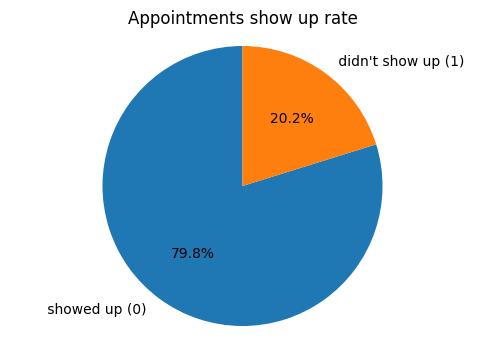

In [11]:
#visualize the No_show with pie chart

plt.figure(figsize=(6,4))
plt.pie((df["No_show"].value_counts()),labels =[ " showed up (0) " , " didn't show up (1) " ], autopct = "%1.1f%%" , startangle = 90)
plt.title("Appointments show up rate")
plt.axis("equal")
plt.show()

In [12]:
#So now we cheak our 2nd hypothesis first and for that we do feature enginnering and add some new column

df["wait_day"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days

print(df["wait_day"].describe())
print()
print("Negitive wait days : ",(df["wait_day"] < 0).sum())

count   110527.00
mean         9.18
std         15.25
min         -7.00
25%         -1.00
50%          3.00
75%         14.00
max        178.00
Name: wait_day, dtype: float64

Negitive wait days :  38568


- As we can see their are 25% vaule with -1 and 38k value is negative this is not small number.
- As we can see in the AppointmentDay column all the time is 00:00:00 means all the appointments have no time they stored at mid-night.
- So for -1 and -2 is time stripping issue so change this vaule with 0.
- And for <-2 vaule, practically this is a data entry error bacause no one can get appointments before scheduled day.
- So for <-2 we assume this data shuffled, and we just swap them(remove negative sign).

In [13]:
#Fix the new column problem

df.loc[df["wait_day"].between(-2,-1) , "wait_day"] = 0

df.loc[df["wait_day"] < -2 , "wait_day"] = df.loc[df["wait_day"] < -2 , "wait_day"].abs()

print(df["wait_day"].describe())
print("Negative wait days : " , (df["wait_day"] < 0).sum())

count   110527.00
mean         9.53
std         15.03
min          0.00
25%          0.00
50%          3.00
75%         14.00
max        178.00
Name: wait_day, dtype: float64
Negative wait days :  0


- Now we have two hypothesis
- **1st** : Weekday → do patients skip Friday appointments more? 
          (long weekend coming, they forget)
- **2nd** : Hour    → do evening bookings (5-6pm) have more no-shows?
          (booked impulsively after work, forget by appointment day)

In [14]:
#Add two more feature

df["appt_weekday"] = df["AppointmentDay"].dt.dayofweek

df["scheduled_hour"] = df["ScheduledDay"].dt.hour

df[['AppointmentDay', 'appt_weekday', 'ScheduledDay', 'scheduled_hour']].head()

,AppointmentDay,appt_weekday,ScheduledDay,scheduled_hour
0,2016-04-29 00:00:00+00:00,4,2016-04-29 18:38:08+00:00,18
1,2016-04-29 00:00:00+00:00,4,2016-04-29 16:08:27+00:00,16
2,2016-04-29 00:00:00+00:00,4,2016-04-29 16:19:04+00:00,16
3,2016-04-29 00:00:00+00:00,4,2016-04-29 17:29:31+00:00,17
4,2016-04-29 00:00:00+00:00,4,2016-04-29 16:07:23+00:00,16


In [15]:
#Last feature 

df["age_groups"] = pd.cut(df["Age"],bins=[0,12,17,35,60,float("inf")],labels=["Child","Teenager","Young Adult","Middle Aged","Senior"]
                          ,include_lowest=True)

age_group_order = {
    "Child": 1,
    "Teenager": 2,
    "Young Adult": 3,
    "Middle Aged": 4,
    "Senior": 5
}

df["age_group_order"] = df["age_groups"].map(age_group_order)

In [16]:
print(df['age_groups'].value_counts())
print(df['age_groups'].isnull().sum())

age_groups
Middle Aged    37762
Young Adult    25624
Child          21036
Senior         19762
Teenager        6343
Name: count, dtype: int64
0


In [17]:
# Final cleaning summary
print('Shape:', df.shape)
print('Dtypes:\n', df.dtypes)
print('Nulls:\n', df.isnull().sum())
print('Negative wait day:', (df['wait_day'] < 0).sum())
print('Columns:', df.columns.tolist())

Shape: (110527, 19)
Dtypes:
 PatientId                      float64
AppointmentID                    int64
Gender                             str
ScheduledDay       datetime64[us, UTC]
AppointmentDay     datetime64[us, UTC]
Age                              int64
Neighbourhood                      str
Scholarship                      int64
Hypertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handicap                         int64
SMS_received                     int64
No_show                          int64
wait_day                         int64
appt_weekday                     int32
scheduled_hour                   int32
age_groups                    category
age_group_order               category
dtype: object
Nulls:
 PatientId          0
AppointmentID      0
Gender             0
ScheduledDay       0
AppointmentDay     0
Age                0
Neighbourhood      0
Scholarship        0
Hypertension       0
Diabetes           

In [18]:
#Now we check our frist hypothesis

sms_check = df.groupby("SMS_received")["No_show"].mean()

In [19]:
sms_check

SMS_received
0   0.17
1   0.28
Name: No_show, dtype: float64

In [20]:
sms_check_with_wait_day = df.groupby("SMS_received")["wait_day"].mean()

In [21]:
sms_check_with_wait_day

SMS_received
0    5.52
1   18.02
Name: wait_day, dtype: float64

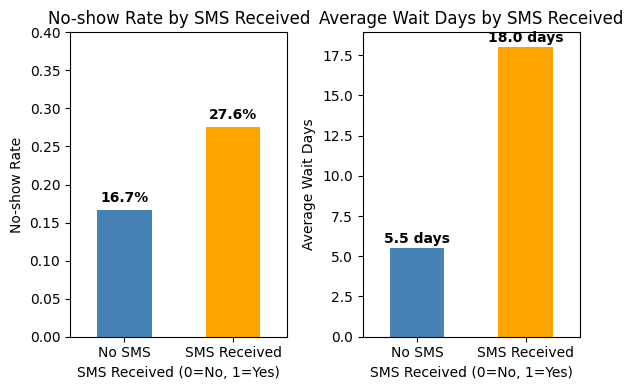

In [22]:
fig, ax = plt.subplots(1,2,figsize=(6, 4))
sms_check.plot(kind='bar', color=['steelblue', 'orange'], ax=ax[0])
ax[0].set_title('No-show Rate by SMS Received')
ax[0].set_xlabel('SMS Received (0=No, 1=Yes)')
ax[0].set_ylabel('No-show Rate')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['No SMS', 'SMS Received'], rotation=0)
ax[0].set_ylim(0, 0.4)

for i, v in enumerate(sms_check):
    ax[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

sms_check_with_wait_day.plot(kind='bar', color=['steelblue', 'orange'], ax=ax[1])
ax[1].set_title('Average Wait Days by SMS Received')
ax[1].set_xlabel('SMS Received (0=No, 1=Yes)')
ax[1].set_ylabel('Average Wait Days')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['No SMS', 'SMS Received'], rotation=0)

for i, v in enumerate(sms_check_with_wait_day):
    ax[1].text(i, v + 0.3, f'{v:.1f} days', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- This data shows that the patient who recevied sms have higher rate to noshow
- Is that mean sms is useless??
- NO. This happend because the hospital share the sms only who have long wait(as reminder),short time no sms needed
- sms_check_with_wait_day confirme it that confounding variable behind H1
- So problem is long wait time(onfounding variable), not sms

- So our first hypothesis **H1 rejected** because of confusing variable 

In [23]:
#Now move to the 2nd hypothesis

df["wait_group"] = pd.cut(df["wait_day"],bins=[-1,0,7,30,90,float("inf")],labels=['Same Day', '1 Week', '1 Month', '1-3 Months', '3+ Months'])

wait_day_check = df.groupby("wait_group")["No_show"].mean()

wait_day_check
wait_group_order = {
    "Same Day": 1,
    "1 Week": 2,
    "1 Month": 3,
    "1-3 Months": 4,
    "3+ Months": 5
}

df["wait_group_order"] = df["wait_group"].map(wait_group_order)

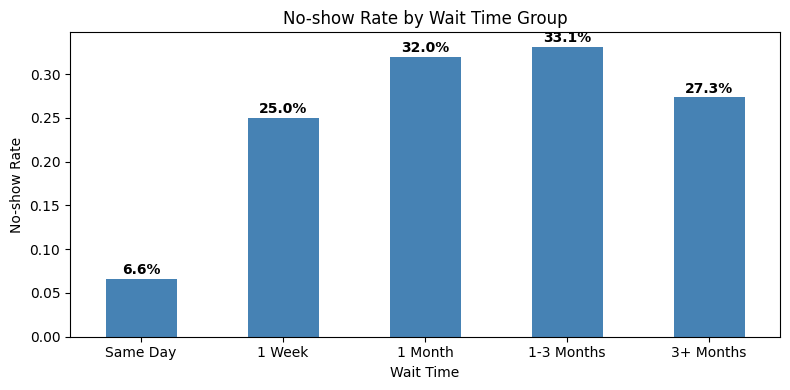

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
wait_day_check.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('No-show Rate by Wait Time Group')
ax.set_xlabel('Wait Time')
ax.set_ylabel('No-show Rate')
ax.set_xticklabels(wait_day_check.index, rotation=0)

for i, v in enumerate(wait_day_check):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- **H2 CONFIRMED** — but with nuance
- No-show rate rises with wait time: 7% → 25% → 32% → 33%
- Exception: 3+ months drops to 27%
- Reason: chronic disease patients dominate long-wait group
- They are habitual hospital visitors → lower no-show tendencym

In [25]:
#Now we check 3rd hypothesis

h3 = df.groupby('Neighbourhood')['No_show'].mean()

h3

Neighbourhood
AEROPORTO             0.12
ANDORINHAS            0.23
ANTÔNIO HONÓRIO       0.18
ARIOVALDO FAVALESSA   0.22
BARRO VERMELHO        0.22
                      ... 
SÃO JOSÉ              0.22
SÃO PEDRO             0.21
TABUAZEIRO            0.18
UNIVERSITÁRIO         0.21
VILA RUBIM            0.17
Name: No_show, Length: 81, dtype: float64

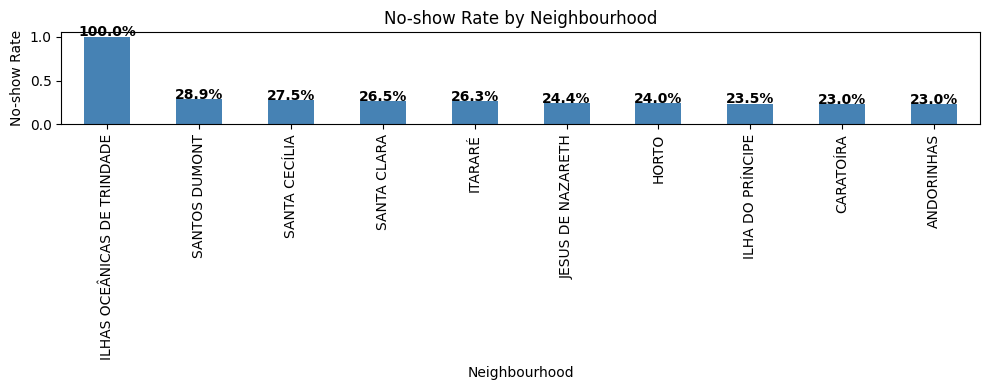

In [26]:
h3_top_10 = h3.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
h3_top_10.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('No-show Rate by Neighbourhood')
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('No-show Rate')
ax.set_xticklabels(h3_top_10.index, rotation=90)

for i, v in enumerate(h3_top_10):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
df[df["Neighbourhood"]=="ILHAS OCEÂNICAS DE TRINDADE"]["No_show"].value_counts().sum()

np.int64(2)

- Here we can see, we have only two sample in that hospital and which is misleading. We should add the thresold sample size

In [28]:
neighbourhood_counts = df.groupby('Neighbourhood')['No_show'].count()
valid_neighbourhoods = neighbourhood_counts[neighbourhood_counts >= 100].index #We take 100 as thresold value

h3 = df[df['Neighbourhood'].isin(valid_neighbourhoods)]\
     .groupby('Neighbourhood')['No_show'].mean()\
     .sort_values(ascending=False)\
     .head(10)

print(h3)

Neighbourhood
SANTOS DUMONT       0.29
SANTA CECÍLIA       0.27
SANTA CLARA         0.26
ITARARÉ             0.26
JESUS DE NAZARETH   0.24
HORTO               0.24
ILHA DO PRÍNCIPE    0.23
CARATOÍRA           0.23
ANDORINHAS          0.23
PRAIA DO SUÁ        0.23
Name: No_show, dtype: float64


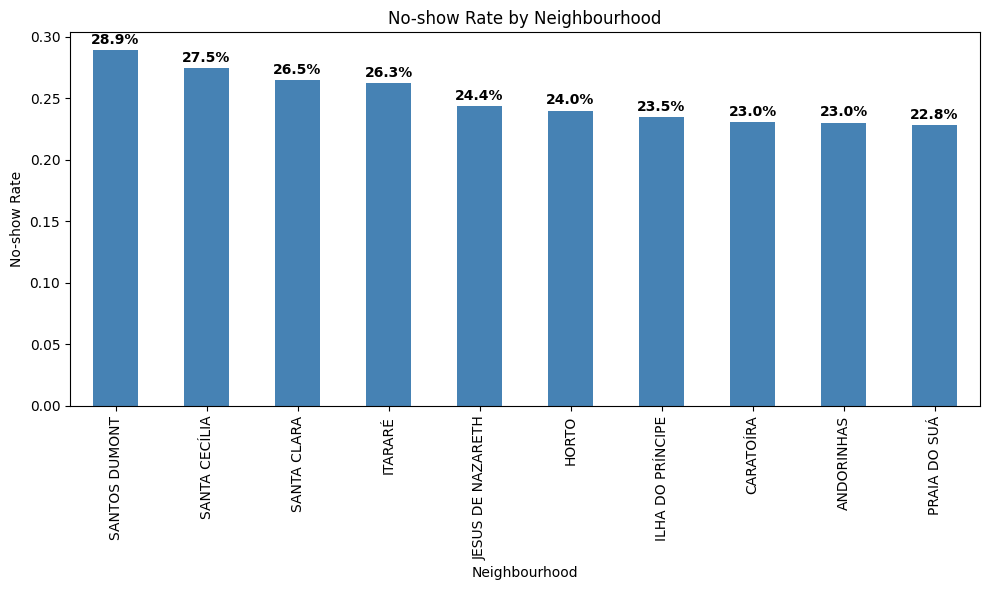

In [29]:
h3_top_10 = h3.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
h3.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('No-show Rate by Neighbourhood')
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('No-show Rate')
ax.set_xticklabels(h3.index, rotation=90)

for i, v in enumerate(h3):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- **H3 CONFIRMED** — neighbourhood affects no-show rate
- Top neighbourhoods show 23-29% vs overall 20.2%
- Small sample neighbourhoods filtered (minimum 100 appointments)
- Possible reasons: transport access, socioeconomic factors, distance to clinic

## First three hypothsis check

- **H1 → Rejected** (confounding variable: wait time)
- **H2 → Confirmed** (longer wait = more no-shows, with chronic patient exception)
- **H3 → Confirmed** (certain neighbourhoods have higher no-show rates)

In [30]:
#Now we also which age group and at which time most of noshow happed and check the hypothesis

age_noshow = df.groupby("age_groups")["No_show"].mean()
print(age_noshow)

day_noshow = df.groupby("scheduled_hour")["No_show"].mean()
print(day_noshow)

age_groups
Child         0.20
Teenager      0.27
Young Adult   0.24
Middle Aged   0.19
Senior        0.15
Name: No_show, dtype: float64
scheduled_hour
6    0.19
7    0.15
8    0.18
9    0.20
10   0.22
11   0.23
12   0.20
13   0.21
14   0.23
15   0.23
16   0.24
17   0.25
18   0.21
19   0.23
20   0.30
21   0.33
Name: No_show, dtype: float64


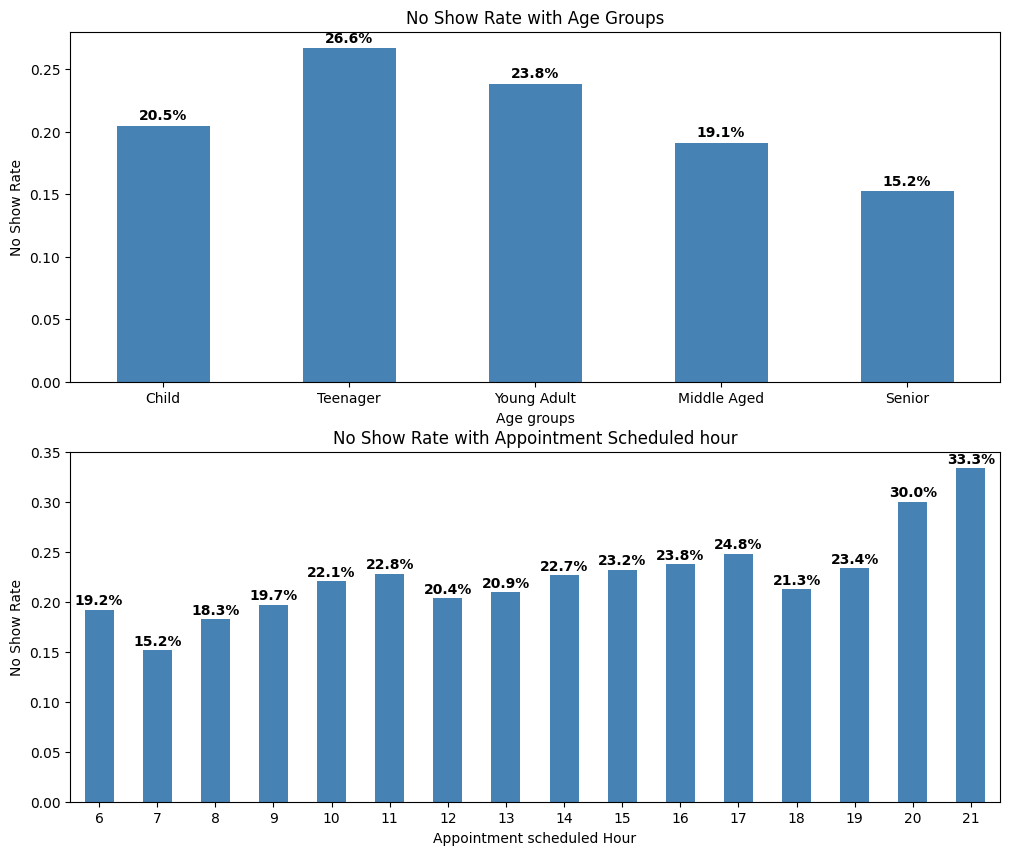

In [31]:
fig,ax = plt.subplots(2,1,figsize=(12,10))

age_noshow.plot(kind="bar", color='steelblue', ax=ax[0])
ax[0].set_title("No Show Rate with Age Groups")
ax[0].set_xlabel("Age groups")
ax[0].set_ylabel("No Show Rate")
ax[0].set_xticklabels(age_noshow.index,rotation=0)

for i,v in enumerate(age_noshow):
    ax[0].text(i, v+0.005, f'{v:.1%}', ha = "center", fontweight = "bold")

day_noshow.plot(kind="bar", color='steelblue', ax=ax[1])
ax[1].set_title("No Show Rate with Appointment Scheduled hour")
ax[1].set_xlabel("Appointment scheduled Hour")
ax[1].set_ylabel("No Show Rate")
ax[1].set_xticklabels(day_noshow.index,rotation=0)

for i,v in enumerate(day_noshow):
    ax[1].text(i, v+0.005, f'{v:.1%}', ha = "center",fontweight = "bold")

plt.show()

- **H4**: Teenagers highest (26.6%) — appointments booked by parents,parent forgets or work conflicts
  ess personal ownership. Seniors lowest (15.2%) — routine chronic care visits.

- **H5**: Evening bookings (20-21hr) highest no-show (30-33%) — Booked impulsively, forgotten by appointment day.
  Early morning (7hr) lowest — motivated, planned patients.

# Final all hypothesis check

- **H1 → Rejected**  (SMS confounded by wait time)
- **H2 → Confirmed** (wait time drives no-shows, chronic exception)
- **H3 → Confirmed** (neighbourhood matters, filter small samples)
- **H4 → Confirmed** (teenagers highest, seniors lowest)   
- **H5 → Confirmed** (evening bookings = more no-shows)

- Now we connect python to the postgresql server 

In [35]:
db_user = "postgres"
db_pass = "PASSWORD" #Write your password
db_host = "localhost"
db_port = "5432"
db_name = "hospital_db"

In [33]:
from sqlalchemy import create_engine,text

connection_string = (f"postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")
engine = create_engine(connection_string, pool_pre_ping = True)

try:
    with engine.connect() as ec:
        print("Connected successfully")
except Exception as ec:
    print(f"Not connected!{ec}")

Connected successfully


In [34]:
insert_rows = df.to_sql(
    name = "appointments",
    con = engine,
    if_exists = "replace",
    index = False,
    method = "multi",
    chunksize = 500
)

print("Rows inserted successfully",insert_rows)    

Rows inserted successfully 110527
